# Description
```
Name      : gan_1
Problem   : Classification
Type      : Deep learning
Algorithm : Convolutional neural network : GAN
Formula   : Weightes-Sum
Action    : Leaky Relu | Softmax
Loss      : sparse_categorical_crossentropy
Train     : Supervised
Input     : Feature and label
Output    : Classification
Dataset   : Structured : mnist
```

# General

### Import

In [124]:
from matplotlib import pyplot as plt
from keras.datasets import mnist
from keras import models, layers
from keras import optimizers
from keras.optimizers.schedules import ExponentialDecay
from keras.models import load_model

### Variable

In [125]:
root_dir = '/Volumes/data/documents/ai_document'
output_label = ['negative', 'positive']
colors = [(255, 0, 0), (0, 255, 0)]

# Separate tarin and test

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print(x_test.shape)
print(len(y_train))
print(len(y_test))

(60000, 28, 28)
(10000, 28, 28)
60000
10000


In [ ]:
x_train, x_test = x_train/255, x_test/255
x_train = x_train.reshape((len(x_train), 28, 28, 1))
x_test = x_test.reshape((len(x_test), 28, 28, 1))

# Model

### Optimizers

In [128]:
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=255,
    decay_rate=0.001,
    staircase=False
)

opt_sgd = optimizers.SGD(learning_rate=lr_schedule)
opt_adam = optimizers.Adam(learning_rate=lr_schedule)

### Sequential

In [129]:
mdl_sequential = models.Sequential()
mdl_sequential.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
mdl_sequential.add(layers.MaxPool2D(pool_size=(2, 2))) 
mdl_sequential.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
mdl_sequential.add(layers.MaxPool2D(pool_size=(2, 2)))
mdl_sequential.add(layers.Flatten())
mdl_sequential.add(layers.Dense(80, activation="relu"))
mdl_sequential.add(layers.Dense(10, activation="softmax"))
mdl_sequential.compile(optimizer=opt_adam, loss="binary_crossentropy", metrics=["accuracy"])
#mdl_sequential.summary()

### Functional

In [130]:
input_layer = layers.Input(shape = (28, 28, 1))
x = layers.Conv2D(32, (3, 3), strides= (2,2))(input_layer)
x = layers.LeakyReLU(negative_slope=0.1)(x)
#x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Conv2D(64, (3, 3), strides= (2,2))(x)
x = layers.LeakyReLU(negative_slope=0.1)(x)
#x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dense(80)(x)
x = layers.LeakyReLU(negative_slope=0.1)(x)
output_layer = layers.Dense(10, activation="softmax")(x)
mdl_functional = models.Model(inputs=input_layer, outputs=output_layer)
mdl_functional.compile(optimizer=opt_adam, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
#mdl_sequential.summary()

### Select

In [131]:
mdl = mdl_functional

# Train

In [132]:
EPOCHS = 5
BATCH_SIZE = 16

In [133]:
h = mdl.fit(
    x_train, 
    y_train, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
    validation_data=(x_test, y_test)
)

Epoch 1/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8184 - loss: 0.6305 - val_accuracy: 0.8600 - val_loss: 0.5126
Epoch 2/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8469 - loss: 0.5397 - val_accuracy: 0.8600 - val_loss: 0.5126
Epoch 3/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8477 - loss: 0.5380 - val_accuracy: 0.8600 - val_loss: 0.5126
Epoch 4/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8471 - loss: 0.5415 - val_accuracy: 0.8600 - val_loss: 0.5126
Epoch 5/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8488 - loss: 0.5360 - val_accuracy: 0.8600 - val_loss: 0.5126


# Evaluation

### Loss and Accuracy

In [134]:
loss, accuracy = mdl.evaluate(x_test, y_test)
print("Loss: {:.2f} | Accuracy: {:.2f}".format(loss, accuracy))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - accuracy: 0.8392 - loss: 0.5789
Loss: 0.51 | Accuracy: 0.86


### History

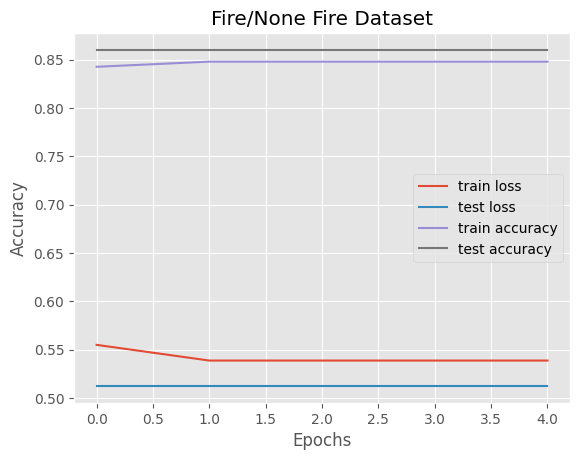

In [135]:
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='test loss')
plt.plot(h.history['accuracy'], label='train accuracy')
plt.plot(h.history['val_accuracy'], label='test accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Fire/None Fire Dataset')
plt.style.use('ggplot')
plt.show()

# Save model

In [136]:
mdl_sequential.save(f"{root_dir}/model/gan_1.h5")